In [ ]:
# pip install matplotlib
# pip install scikit-learn
# pip install pandas
# pip install seaborn

In [247]:
import pandas as pd
from matplotlib import pyplot as plt

In [248]:
df = pd.read_csv("tft_champions_all_sets.csv")
print(df.shape)
df.head()

(1181, 14)


,set,cost,key,traits,health,attackDamage,damagePerSecond,attackRange,attackSpeed,armor,magicalResistance,skill.startingMana,skill.skillMana,skill.stats
0,1,"[3, 5, 7]",Aatrox,"['Demon', 'Blademaster']","[700, 1260, 2268]","[65, 117, 211]","[42, 76, 137]",1,0.65,35,20,0,75,"[300, 600, 900]"
1,1,"[2, 4, 6]",Ahri,"['Wild', 'Sorcerer']","[450, 810, 1458]","[50, 90, 162]","[28, 50, 89]",3,0.55,20,20,0,75,"[100, 200, 300]"
2,1,"[4, 6, 8]",Akali,"['Ninja', 'Assassin']","[650, 1170, 2106]","[80, 144, 259]","[64, 115, 207]",1,0.80,20,20,0,25,"[200, 350, 500]"
3,1,"[5, 7, 9]",Anivia,"['Glacial', 'Elementalist']","[750, 1350, 2430]","[40, 72, 130]","[32, 58, 104]",3,0.80,20,20,50,125,"[800, 950, 1200]"
4,1,"[3, 5, 7]",Ashe,"['Glacial', 'Ranger']","[550, 990, 1782.0000000000002]","[65, 117, 211]","[46, 82, 148]",4,0.70,20,20,0,125,"[200, 400, 600]"


In [249]:
no_clean_cols = ["attackRange","attackSpeed","armor","magicalResistance","skill.startingMana","skill.skillMana"]
clean_cols = ["damagePerSecond","attackDamage","health"]

In [250]:
import ast

In [251]:
df["cost"] = df["cost"].apply(ast.literal_eval)
df["traits"] = df["traits"].apply(ast.literal_eval)

def safe_parse(x):
    try:
        return ast.literal_eval(str(x))
    except:
        return []
        
df["skill.stats"] = df["skill.stats"].apply(safe_parse)

In [252]:
df["skill.stat_count"] = df["skill.stats"].apply(lambda x: len(x))
df = df[ df["skill.stat_count"] > 0]
df["skill_stat_1"] = df["skill.stats"].apply(lambda x:x[0])
df = df[ df["skill_stat_1"] > 100]

df["skill.stat_max"] = df["skill.stats"].apply(max)
df["skill.stat_min"] = df["skill.stats"].apply(min)

In [253]:
df["num_of_traits"] = df["traits"].apply(lambda x: len(x))

In [254]:
df["cost_2star"] = df["cost"].apply(lambda x:x[1])
df = df[ df["cost_2star"] != -1]
df["real_cost"] = df["cost"].apply(lambda x:x[0])

In [255]:
for col in clean_cols:
    df = df.dropna(subset=[col])
    if isinstance(df[col].iloc[0], str):
        df[col] = df[col].apply(ast.literal_eval)
    for i in range(3):
        df[f"{col}_{i}"] = df[col].apply(lambda x: x[i])
    df.drop(columns=[col], inplace=True)

In [256]:
cols_to_remove = ["set","cost","key","traits","health","attackDamage","damagePerSecond","skill.stats",'cost_2star',"skill_stat_1","skill.stat_count"]
all_cols = df.columns.tolist()
for col in all_cols:
    if col in cols_to_remove:
        df.drop(columns=col, inplace=True)

In [257]:
df_clean = df[df["real_cost"] <= 5]

In [258]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [259]:
df_clean["real_cost"] = df_clean["real_cost"].astype(int)

In [260]:
y = df_clean["real_cost"].values

In [261]:
features_df = df_clean.drop(columns=["real_cost"])

In [262]:
X = features_df.values

In [263]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=14)

In [264]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [265]:
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

In [266]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 250, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.7448275862068965


In [267]:
rand_forest_model = RandomForestClassifier(max_depth= None, min_samples_leaf=1, min_samples_split= 5, n_estimators= 250, random_state=42)
rand_forest_model.fit(X_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [268]:
y_pred = rand_forest_model.predict(X_test_scaled)

In [269]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"confusion matrix = {cm}")
print(f"accuracy score = {accuracy}")

confusion matrix = [[30  5  1  0  0]
 [ 7 17  4  0  0]
 [ 0  9 33  2  0]
 [ 1  1  3 15  3]
 [ 0  0  1  5  9]]
accuracy score = 0.7123287671232876


In [270]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.79      0.83      0.81        36
           2       0.53      0.61      0.57        28
           3       0.79      0.75      0.77        44
           4       0.68      0.65      0.67        23
           5       0.75      0.60      0.67        15

    accuracy                           0.71       146
   macro avg       0.71      0.69      0.70       146
weighted avg       0.72      0.71      0.71       146



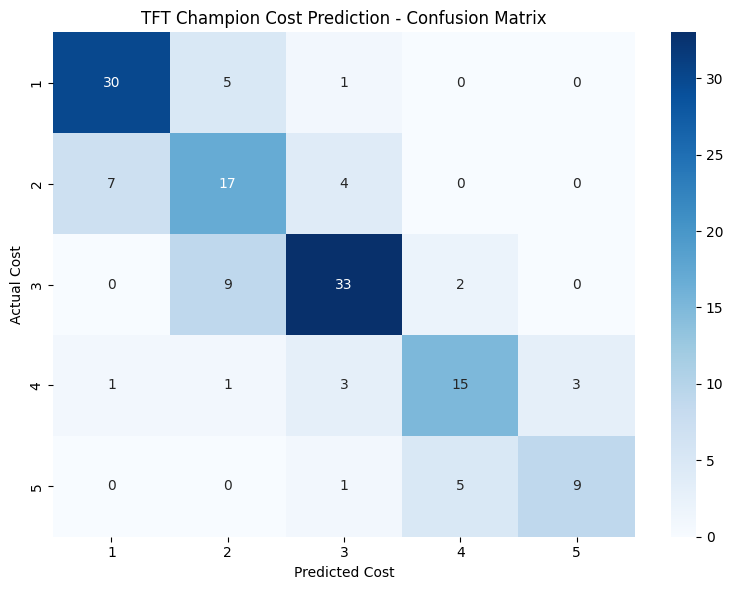

In [271]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted Cost')
plt.ylabel('Actual Cost')
plt.title('TFT Champion Cost Prediction - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

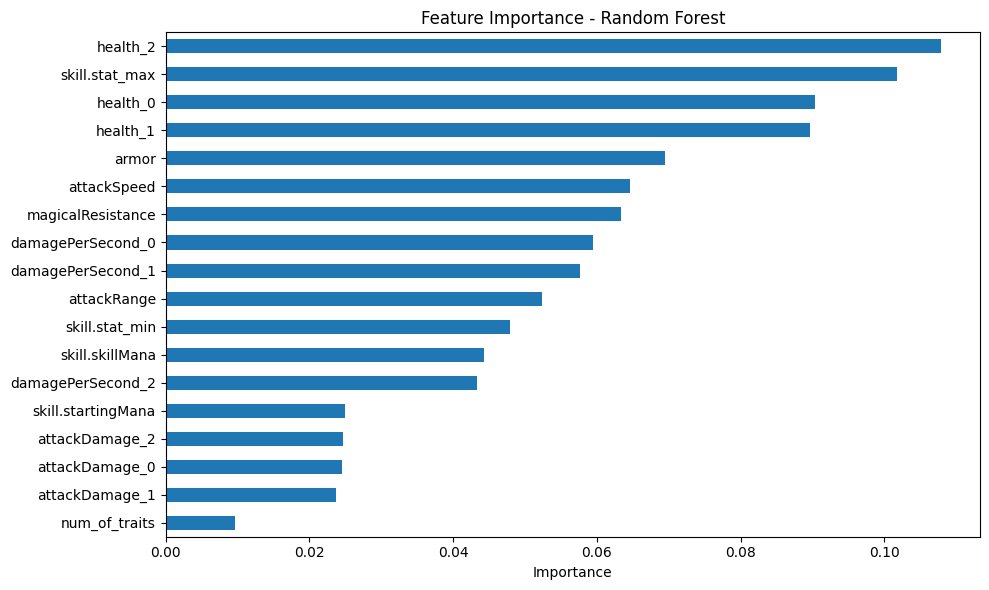

In [272]:
feat_imp = pd.Series(rand_forest_model.feature_importances_, index=features_df.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()